![project banner.png](https://i.postimg.cc/s2Jfw9Qd/Project-Banner.png)]
# NHL Data Analysis (2004-2018)
### CS3120 - Machine Learning
### Final Project — Part 2  (ANDY RUZICKA)

This notebook looks to investigate three questions about NHL skater performance using a
seasonal player statistics dataset spanning from the 2004-05 season all the way through to the 2017-18 season. 
Also, for certain sections, we will be mainly focused on the three most recent seasons in the dataset (2015-2016 through 2017-2018).

**Sourced Dataset:** [NHL Player Stats 2004-2018](https://www.kaggle.com/datasets/xavya77/nhl04to18) (Kaggle)(Author: Xavya77).

Each row represents a single player's regular-season statistics in a single season. 

## **My Three Research Questions / Hypotheses:**

1. **`Can a Player's Total Points (Goals + Assists) Be Predicted From Their Peripheral Statistics, like Specifically Time On Ice, Shots On Goal, Age, Position, and Games Played?`**
2. **`Can We Classify Whether a Player is a Forward or a Defenseman Using Only
   Their Player Profile Statistics (NOT the position label)?`**
3. **`Does a Player's Age Have a Measurable Relationship with Their Offensive Production, and is there a "Golden Age" Curve?`**
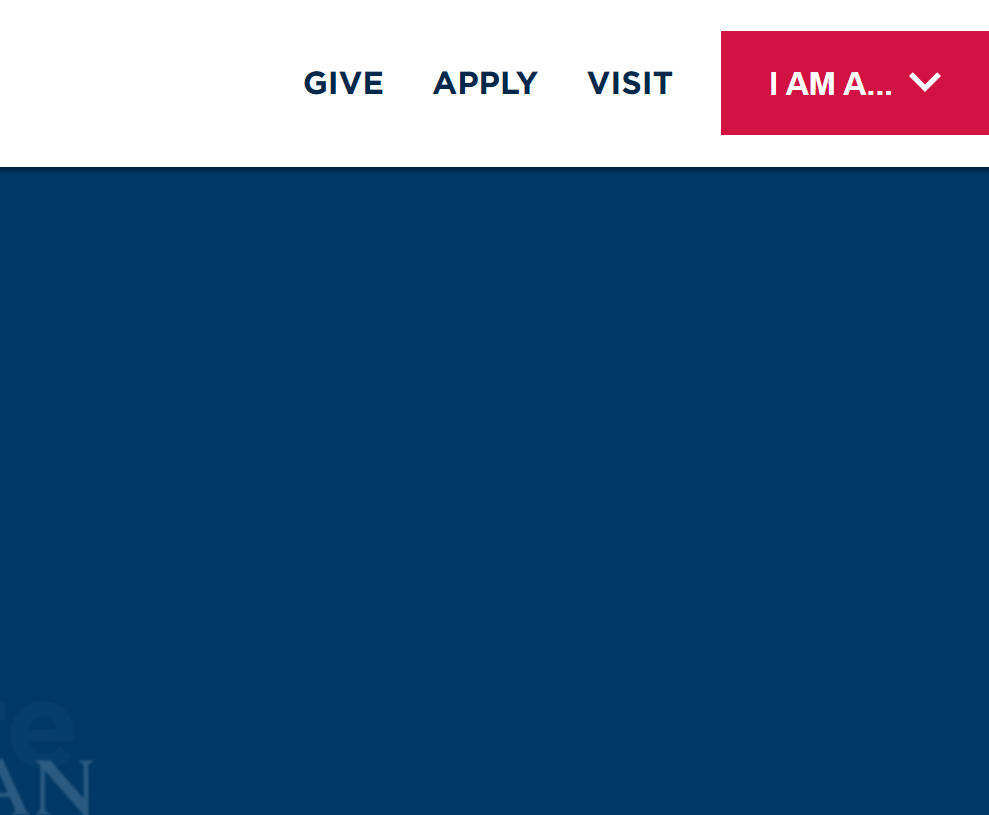
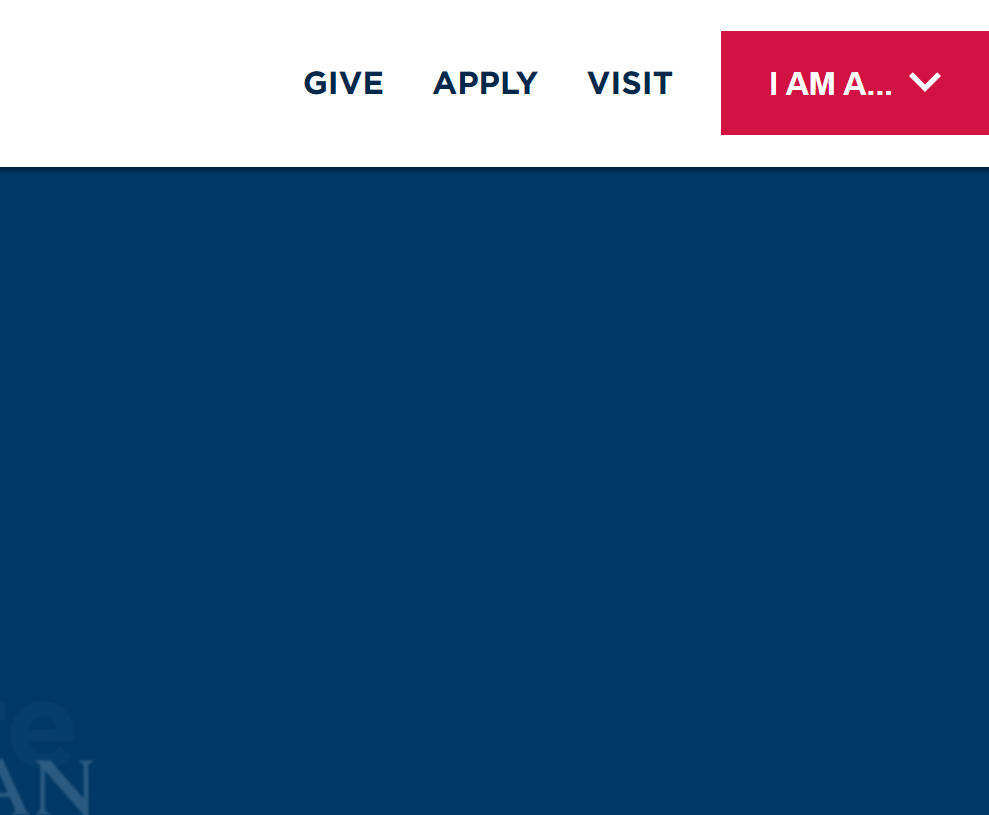

## 1. Setup and Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier
)
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Data Loading and Cleaning

The raw dataset contains 13,186 player-seasons across 14 NHL seasons. To keep
the project focused, we'll filter to the **three most recent seasons (2015-16
through 2017-18)**, drop low-sample observations, handle the small number of
missing values, and clean the position labels.

In [5]:
import glob
DATA_PATH = glob.glob('/kaggle/input/**/nhl_data.csv', recursive=True)[0]
print(f"Using data file: {DATA_PATH}")

#Load Raw Data
df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f"Raw data shape: {df_raw.shape}")
print(f"Seasons available: {sorted(df_raw['Season'].unique())}")
df_raw.head()

Using data file: /kaggle/input/datasets/andyrose18/nhl-data/nhl_data.csv
Raw data shape: (13186, 31)
Seasons available: [np.int64(2004), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


,Rk,Player,Age,Pos,Tm,GP,G,A,PTS,plusminus,...,TOI,ATOI,BLK,HIT,FOW,FOL,FO_percent,HART,Votes,Season
0,1,Connor McDavid\mcdavco01,20,C,EDM,82,30,70,100,27,...,1733,21.133333,29.0,34,348.0,458.0,43.2,1,1604,2017
1,2,Sidney Crosby\crosbsi01,29,C,PIT,75,44,45,89,17,...,1491,19.883333,27.0,80,842.0,906.0,48.2,0,1104,2017
2,3,Patrick Kane\kanepa01,28,RW,CHI,82,34,55,89,11,...,1754,21.400000,15.0,28,7.0,44.0,13.7,0,206,2017
3,4,Nicklas Backstrom\backsni02,29,C,WSH,82,23,63,86,17,...,1497,18.266667,33.0,45,685.0,648.0,51.4,0,60,2017
4,5,Nikita Kucherov\kucheni01,23,RW,TBL,74,40,45,85,13,...,1438,19.433333,20.0,30,0.0,0.0,0.0,0,119,2017


In [6]:
# Clean player names (raw format is "Name\\player_id")
df_raw['Player'] = df_raw['Player'].str.split('\\').str[0]

# Filter to the three most recent seasons
df = df_raw[df_raw['Season'].isin([2015, 2016, 2017])].copy()
print(f"After season filter: {df.shape}")

# Drop players with very few games (noise / fringe call-ups)
df = df[df['GP'] >= 10].copy()
print(f"After GP >= 10 filter: {df.shape}")

# Drop the handful of multi-position labels (LW/RW, C/LW, etc.) — under 10 rows total
df = df[df['Pos'].isin(['C', 'LW', 'RW', 'D'])].copy()
print(f"After position cleanup: {df.shape}")

# Handle missing values (only S_percent and FO_percent have any)
df['S_percent'] = df['S_percent'].fillna(0)
df['FO_percent'] = df['FO_percent'].fillna(0)

# The source 'ATOI' column has parsing issues (only the fractional part of the
# time string was preserved). Recompute it as TOI / GP, which gives the true
# average minutes per game.
df['ATOI'] = df['TOI'] / df['GP']

# Engineered targets we'll use later
df['IsForward'] = (df['Pos'] != 'D').astype(int)  # 1 = forward, 0 = defenseman
df['PPG'] = df['PTS'] / df['GP']                   # points per game

print(f"\nFinal cleaned shape: {df.shape}")
print(f"Forwards: {(df['IsForward']==1).sum()}, Defensemen: {(df['IsForward']==0).sum()}")
print(f"ATOI range (min/game): {df['ATOI'].min():.1f} to {df['ATOI'].max():.1f}")

After season filter: (2668, 31)
After GP >= 10 filter: (2202, 31)
After position cleanup: (2197, 31)

Final cleaned shape: (2197, 33)
Forwards: 1438, Defensemen: 759
ATOI range (min/game): 5.5 to 29.1


In [7]:
# Quick sanity check on the cleaned data
df.describe()[['Age', 'GP', 'G', 'A', 'PTS', 'TOI', 'S', 'PPG']].round(2)

,Age,GP,G,A,PTS,TOI,S,PPG
count,2197.00,2197.00,2197.00,2197.00,2197.00,2197.00,2197.00,2197.00
mean,26.72,59.53,8.97,15.15,24.12,987.89,99.71,0.36
std,4.47,22.35,8.64,12.43,19.54,500.75,66.03,0.23
min,18.00,10.00,0.00,0.00,0.00,72.00,3.00,0.00
25%,23.00,44.00,2.00,5.00,8.00,579.00,46.00,0.18
50%,26.00,68.00,6.00,12.00,18.00,1034.00,90.00,0.31
75%,30.00,79.00,14.00,23.00,37.00,1382.00,143.00,0.51
max,44.00,84.00,53.00,70.00,106.00,2378.00,398.00,1.29


## 3. Exploratory Data Analysis

We start with a broad look at the distributions of key variables, then move
into relationships between features and the outcomes we'll be modeling.

### 3.1 Distributions of key offensive stats

Most NHL skaters score relatively few points per season — the distributions of
goals, assists, and total points are heavily right-skewed, with a long tail of
elite scorers.

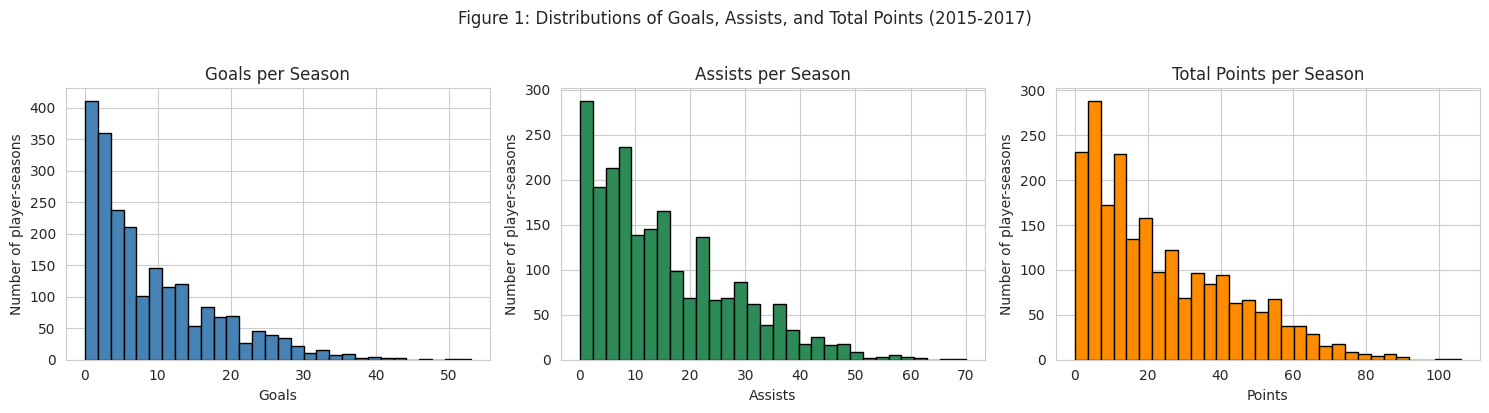

Median PTS: 18
Mean PTS:   24.1
Max PTS:    106 (note: this is one player-season's total)


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['G'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Goals per Season')
axes[0].set_xlabel('Goals'); axes[0].set_ylabel('Number of player-seasons')

axes[1].hist(df['A'], bins=30, color='seagreen', edgecolor='black')
axes[1].set_title('Assists per Season')
axes[1].set_xlabel('Assists'); axes[1].set_ylabel('Number of player-seasons')

axes[2].hist(df['PTS'], bins=30, color='darkorange', edgecolor='black')
axes[2].set_title('Total Points per Season')
axes[2].set_xlabel('Points'); axes[2].set_ylabel('Number of player-seasons')

plt.suptitle('Figure 1: Distributions of Goals, Assists, and Total Points (2015-2017)', y=1.02)
plt.tight_layout()
plt.show()

print(f"Median PTS: {df['PTS'].median():.0f}")
print(f"Mean PTS:   {df['PTS'].mean():.1f}")
print(f"Max PTS:    {df['PTS'].max()} (note: this is one player-season's total)")

### 3.2 Player composition by position and age

The league is composed of roughly twice as many forwards as defensemen (since
each lineup typically has 12 forwards vs 6 defensemen). The age distribution
peaks in the mid-20s — most players enter the league around age 20-22 and
careers taper off after age 32.

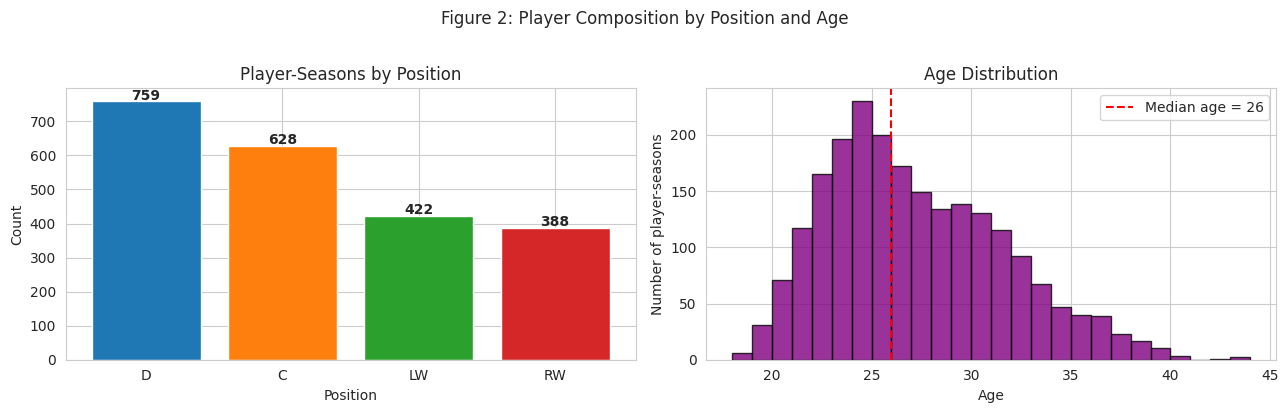

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pos_counts = df['Pos'].value_counts()
axes[0].bar(pos_counts.index, pos_counts.values,
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Player-Seasons by Position')
axes[0].set_xlabel('Position'); axes[0].set_ylabel('Count')
for i, v in enumerate(pos_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].hist(df['Age'], bins=range(18, 45), color='purple',
             edgecolor='black', alpha=0.8)
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Number of player-seasons')
axes[1].axvline(df['Age'].median(), color='red', linestyle='--',
                label=f"Median age = {df['Age'].median():.0f}")
axes[1].legend()

plt.suptitle('Figure 2: Player Composition by Position and Age', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Time on ice strongly predicts points

Time on ice (ATOI, average minutes per game) is highly correlated with
point production. The relationship is roughly linear but the slope differs
by position — forwards convert ice time into points more efficiently than
defensemen, who often play more minutes per game but score fewer points.

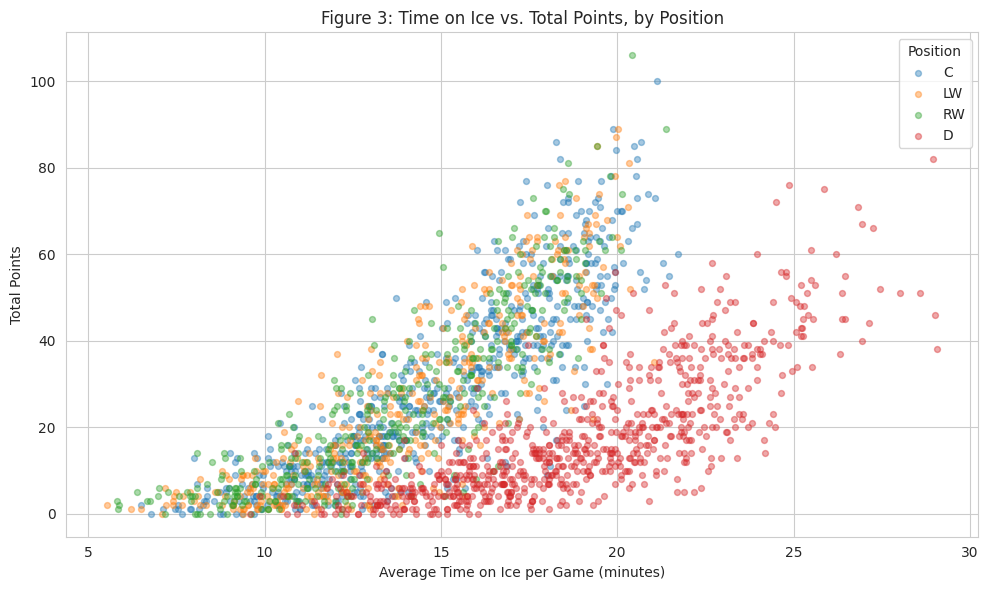

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'C': '#1f77b4', 'LW': '#ff7f0e', 'RW': '#2ca02c', 'D': '#d62728'}
for pos in ['C', 'LW', 'RW', 'D']:
    sub = df[df['Pos'] == pos]
    ax.scatter(sub['ATOI'], sub['PTS'], alpha=0.4, s=18,
               color=colors[pos], label=pos)
ax.set_xlabel('Average Time on Ice per Game (minutes)')
ax.set_ylabel('Total Points')
ax.set_title('Figure 3: Time on Ice vs. Total Points, by Position')
ax.legend(title='Position')
plt.tight_layout()
plt.show()

### 3.4 Forwards vs. Defensemen — different scoring profiles

Box plots make the position split obvious. Defensemen as a group score far
fewer points, fewer goals, and have lower shooting percentages than forwards.
This separation is what makes Question 2 (classifying forwards vs.
defensemen) tractable.

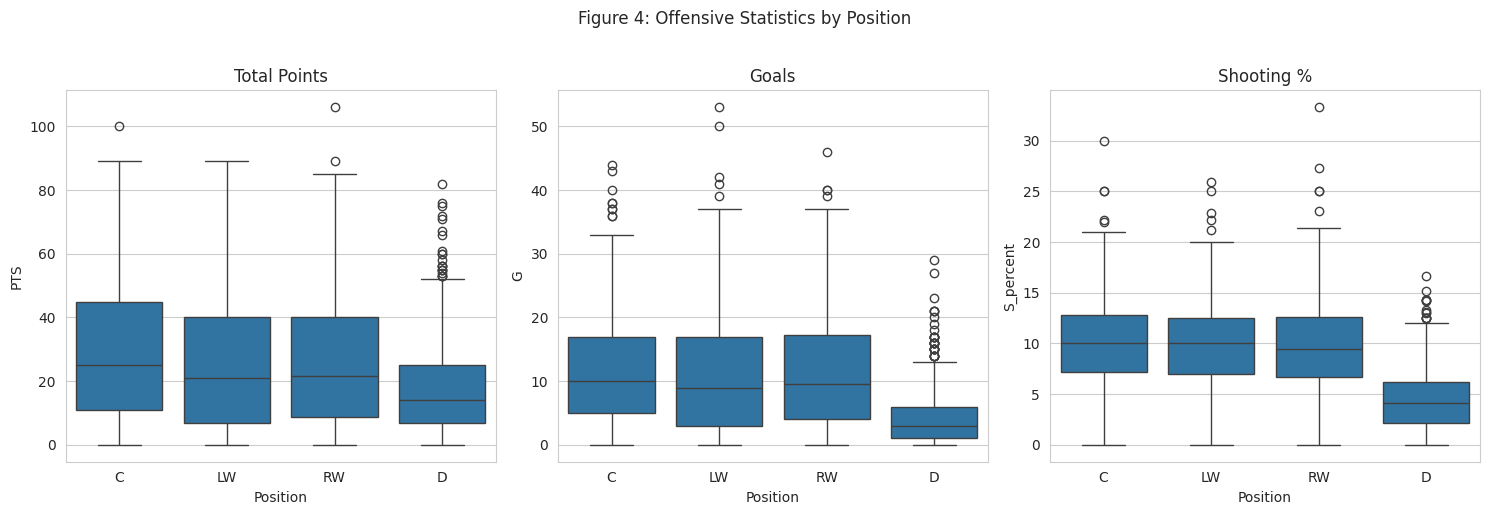

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='Pos', y='PTS',
            order=['C', 'LW', 'RW', 'D'], ax=axes[0])
axes[0].set_title('Total Points'); axes[0].set_xlabel('Position')

sns.boxplot(data=df, x='Pos', y='G',
            order=['C', 'LW', 'RW', 'D'], ax=axes[1])
axes[1].set_title('Goals'); axes[1].set_xlabel('Position')

sns.boxplot(data=df, x='Pos', y='S_percent',
            order=['C', 'LW', 'RW', 'D'], ax=axes[2])
axes[2].set_title('Shooting %'); axes[2].set_xlabel('Position')

plt.suptitle('Figure 4: Offensive Statistics by Position', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Correlation between numeric features

The correlation heatmap shows tight clustering between offensive volume stats
(G, A, PTS, S) and time-related stats (GP, TOI). Defensive stats (BLK, HIT)
correlate weakly with offensive stats, which suggests they'll be useful for
distinguishing forwards from defensemen.

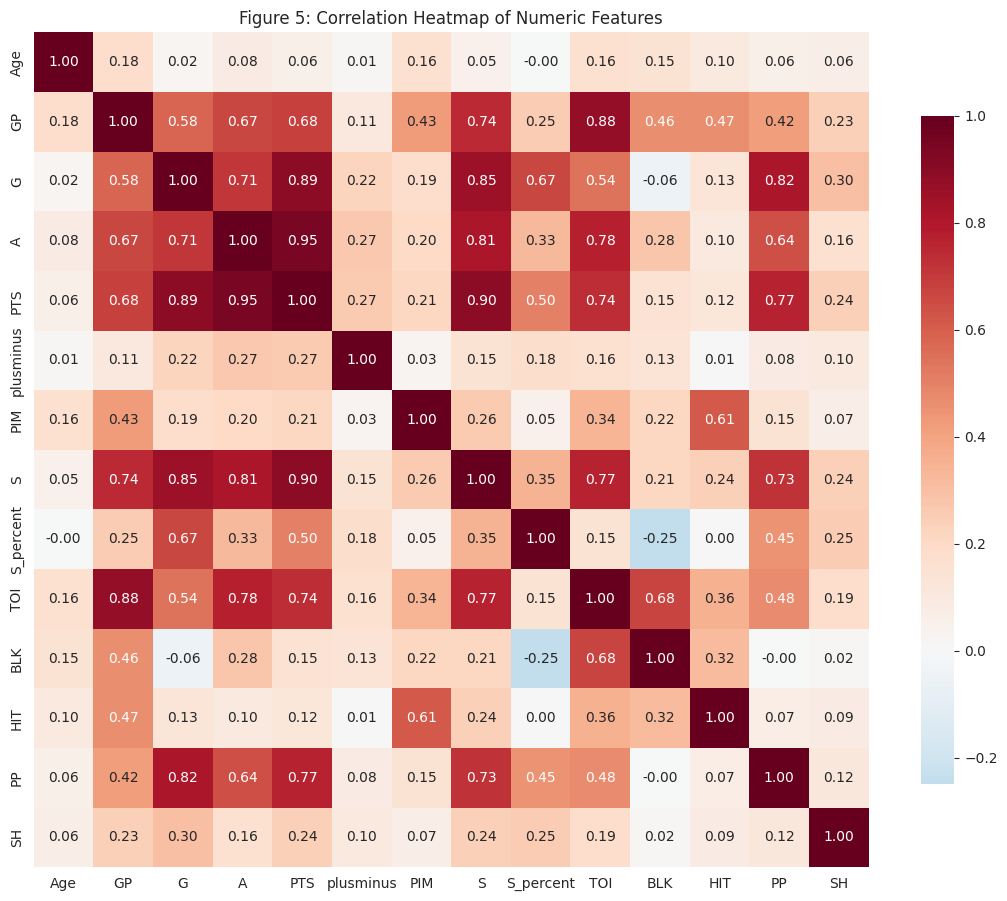

In [12]:
num_cols = ['Age', 'GP', 'G', 'A', 'PTS', 'plusminus', 'PIM',
            'S', 'S_percent', 'TOI', 'BLK', 'HIT', 'PP', 'SH']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Figure 5: Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## 4. |(QUESTION 1)| 
### Predicting Total Points (PTS / Goals + Assists)

> *Can a player's total points be predicted from peripheral statistics like
> time on ice, shots on goal, age, and position?*
>
### **My Hypothesis:** 
> Yes, from opportunities like Time on Ice (TOI) and shot volume, these should be the
> strongest predictors.
>
**My Approach:** I compared three regressors of increasing flexibility:
1. **Linear Regression** (baseline)
2. **Random Forest Regressor**
3. **Gradient Boosting Regressor**

Used a held-out 20% test split, 5-fold cross-validation on the training set,
and report **R²** and **RMSE** for each model.

In [13]:
# Features: peripheral stats only (no goals/assists/PTS leakage)
feat_q1 = ['Age', 'GP', 'TOI', 'S', 'plusminus', 'PIM']
X1 = pd.get_dummies(df[feat_q1 + ['Pos']], columns=['Pos'], drop_first=True)
y1 = df['PTS']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training on {len(X1_train)} player-seasons, testing on {len(X1_test)}")
print(f"Features used: {list(X1.columns)}")

Training on 1757 player-seasons, testing on 440
Features used: ['Age', 'GP', 'TOI', 'S', 'plusminus', 'PIM', 'Pos_D', 'Pos_LW', 'Pos_RW']


In [14]:
# Fit three models and collect metrics
models_q1 = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=200,
                                                random_state=RANDOM_STATE,
                                                n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200,
                                                    random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results_q1 = []

for name, model in models_q1.items():
    model.fit(X1_train, y1_train)
    pred_test = model.predict(X1_test)

    r2_test   = r2_score(y1_test, pred_test)
    rmse_test = np.sqrt(mean_squared_error(y1_test, pred_test))

    cv_r2     = cross_val_score(model, X1_train, y1_train, cv=kf,
                                 scoring='r2').mean()
    cv_rmse   = np.sqrt(-cross_val_score(model, X1_train, y1_train, cv=kf,
                                          scoring='neg_mean_squared_error').mean())

    results_q1.append({
        'Model': name,
        'CV R²': cv_r2,
        'CV RMSE': cv_rmse,
        'Test R²': r2_test,
        'Test RMSE': rmse_test,
    })

results_q1_df = pd.DataFrame(results_q1).round(4)
print("Question 1 — Model comparison:")
results_q1_df

Question 1 — Model comparison:


,Model,CV R²,CV RMSE,Test R²,Test RMSE
0,Linear Regression,0.8572,7.3652,0.8596,7.2060
1,Random Forest,0.8708,7.0060,0.8770,6.7432
2,Gradient Boosting,0.8818,6.7085,0.8872,6.4587


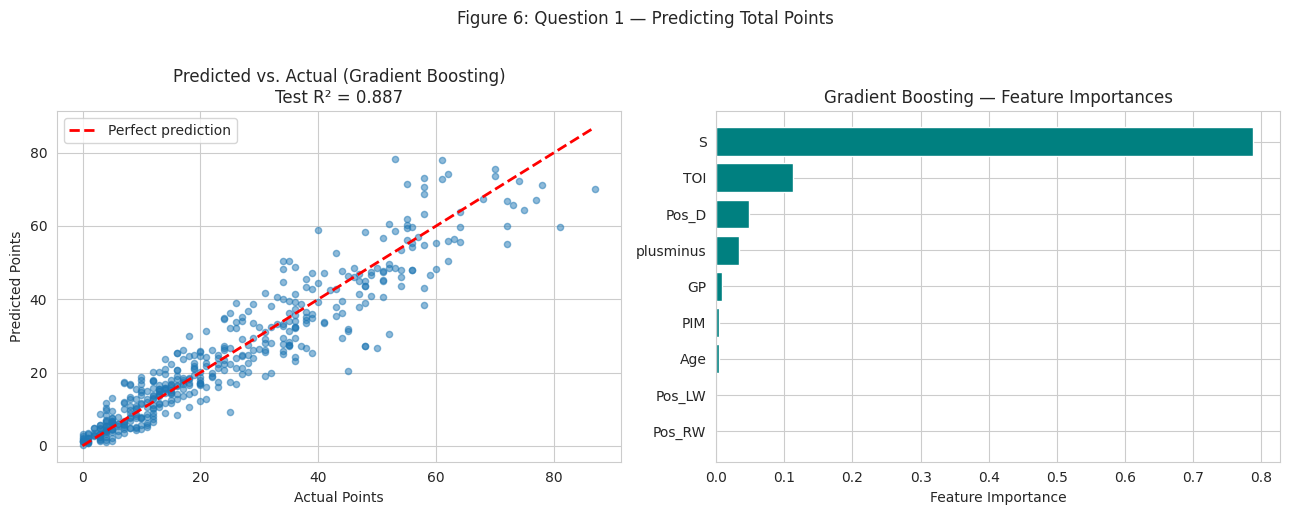

In [15]:
# Predicted vs. Actual plot for the best model (Gradient Boosting)
best_q1 = models_q1['Gradient Boosting']
pred_q1 = best_q1.predict(X1_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y1_test, pred_q1, alpha=0.5, s=20)
mn, mx = min(y1_test.min(), pred_q1.min()), max(y1_test.max(), pred_q1.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title(f'Predicted vs. Actual (Gradient Boosting)\n'
                  f'Test R² = {r2_score(y1_test, pred_q1):.3f}')
axes[0].legend()

# Feature importances
imp = pd.Series(best_q1.feature_importances_,
                index=X1.columns).sort_values()
axes[1].barh(imp.index, imp.values, color='teal')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Gradient Boosting — Feature Importances')

plt.suptitle('Figure 6: Question 1 — Predicting Total Points', y=1.02)
plt.tight_layout()
plt.show()

## 5. |(QUESTION 2)| 
### Classifying Forward vs. Defenseman

> *Can we classify whether a player is a forward or a defenseman using only
> their statistical profile (without seeing the position label)?*
>
### **My Hypothesis:** 
> Yes. Defensemen and forwards should have very
> measurably different/distinct statistical profiles.

**My Approach:** Two classifiers:
1. **Logistic Regression** (baseline, with standardized features)
2. **Random Forest Classifier**

Reporting accuracy, ROC-AUC, and a confusion matrix. As a recommendation from the professor,
he asked me to also report **R²** for this hypothesis. Computed it on the
**predicted probabilities vs. the binary outcome** for binary classification
this quantity is known as **Tjur's R² / "discrimination R²"** and gives a
useful sense of how well the model separates the two classes in probability
space.

In [16]:
feat_q2 = ['G', 'A', 'S', 'S_percent', 'plusminus',
            'BLK', 'HIT', 'PIM', 'PP', 'SH']
X2 = df[feat_q2].copy()
y2 = df['IsForward']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2)

# Standardize for Logistic Regression
scaler = StandardScaler()
X2_train_sc = scaler.fit_transform(X2_train)
X2_test_sc  = scaler.transform(X2_test)

print(f"Training: {len(X2_train)} (forwards={y2_train.sum()}, "
      f"defensemen={(y2_train==0).sum()})")

Training: 1757 (forwards=1150, defensemen=607)


In [17]:
# Two classifiers
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X2_train_sc, y2_train)
prob_lr = logreg.predict_proba(X2_test_sc)[:, 1]
pred_lr = logreg.predict(X2_test_sc)

rfc = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                              n_jobs=-1)
rfc.fit(X2_train, y2_train)
prob_rf = rfc.predict_proba(X2_test)[:, 1]
pred_rf = rfc.predict(X2_test)

# Cross-val for both
cv_acc_lr = cross_val_score(logreg, scaler.transform(X2),
                             y2, cv=kf, scoring='accuracy').mean()
cv_acc_rf = cross_val_score(rfc, X2, y2, cv=kf, scoring='accuracy').mean()

results_q2 = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'CV Accuracy': cv_acc_lr,
        'Test Accuracy': accuracy_score(y2_test, pred_lr),
        'Test AUC': roc_auc_score(y2_test, prob_lr),
        'R² (on probabilities)': r2_score(y2_test, prob_lr),
    },
    {
        'Model': 'Random Forest',
        'CV Accuracy': cv_acc_rf,
        'Test Accuracy': accuracy_score(y2_test, pred_rf),
        'Test AUC': roc_auc_score(y2_test, prob_rf),
        'R² (on probabilities)': r2_score(y2_test, prob_rf),
    },
]).round(4)

print("Question 2 — Model comparison:")
results_q2

Question 2 — Model comparison:


,Model,CV Accuracy,Test Accuracy,Test AUC,R² (on probabilities)
0,Logistic Regression,0.9445,0.9477,0.9820,0.7984
1,Random Forest,0.9440,0.9455,0.9804,0.7890


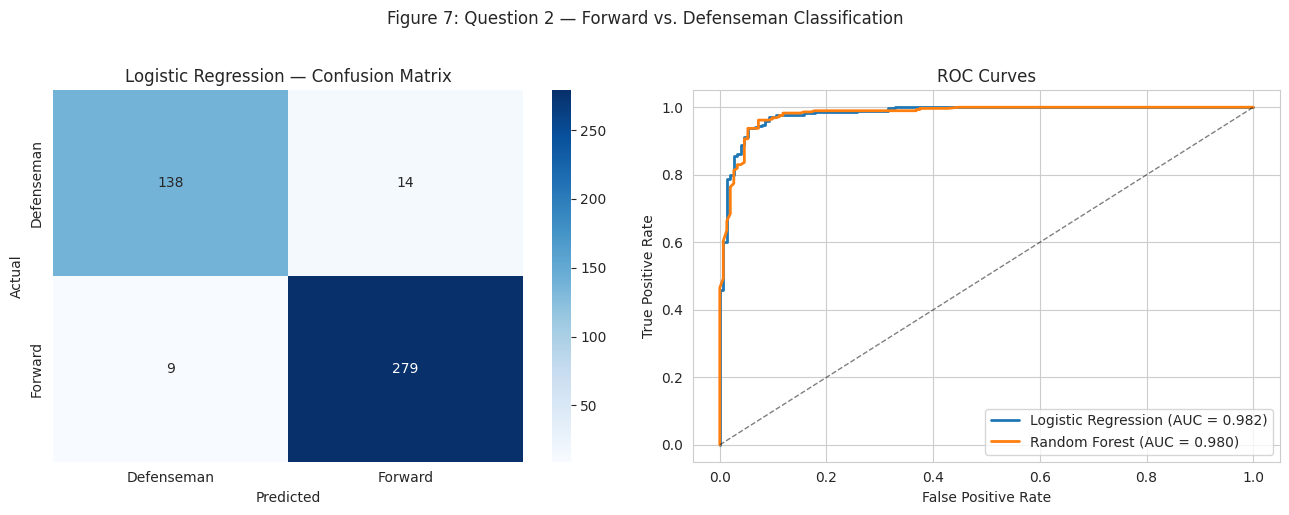

In [18]:
# Confusion matrix and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y2_test, pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Defenseman', 'Forward'],
            yticklabels=['Defenseman', 'Forward'])
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

for label, prob in [('Logistic Regression', prob_lr), ('Random Forest', prob_rf)]:
    fpr, tpr, _ = roc_curve(y2_test, prob)
    auc = roc_auc_score(y2_test, prob)
    axes[1].plot(fpr, tpr, lw=2, label=f'{label} (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')

plt.suptitle('Figure 7: Question 2 — Forward vs. Defenseman Classification',
             y=1.02)
plt.tight_layout()
plt.show()

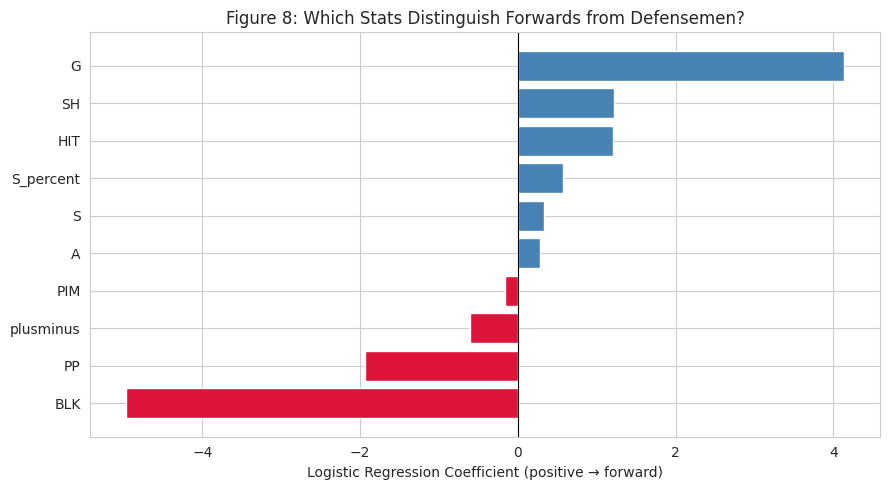

Negative coefficients => stat is more typical of defensemen
Positive coefficients => stat is more typical of forwards


In [19]:
# Logistic regression coefficients — which stats most distinguish forwards from D?
coef_df = pd.DataFrame({
    'feature': feat_q2,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Logistic Regression Coefficient (positive → forward)')
ax.set_title('Figure 8: Which Stats Distinguish Forwards from Defensemen?')
plt.tight_layout()
plt.show()

print("Negative coefficients => stat is more typical of defensemen")
print("Positive coefficients => stat is more typical of forwards")

## 6. |(QUESTION 3)| 
### "Golden Age" Curve via Model Explainability

> *Does a player's age have a measurable relationship with offensive
> production, and is there a "golden age" curve?*
>
### **My Hypothesis:** 
> Yes, we can see production rises through the early-to-mid 20s, peaks
> around ages 25-28, and gradually declines after 30.

**My Approach:** Following the professor's recommendation, instead of a simple
polynomial regression, I decided to fit a **Gradient Boosting regressor** of points-per-game
(PPG) on age and position, then inspect what the model learned using:

1. **Permutation Importance** — quantifies how much each feature contributes
2. **Partial Dependence Plot (PDP)** — shows the average effect of age on
   predicted PPG, marginalized over the other features
3. **Individual Conditional Expectation (ICE) plot** — shows the age effect for
   individual players, revealing whether the average masks heterogeneity

Restricting to players with at least 40 games played (regular roster players)
to reduce noise from injury-shortened or call-up seasons.

In [20]:
# Restrict to "regulars" (GP >= 40) and to a reasonable age range (20-38)
# to avoid sparse extremes (very few players at age 18-19 or 40+)
reg = df[(df['GP'] >= 40) & (df['Age'].between(20, 38))].copy()
print(f"Regular roster players age 20-38: {len(reg)} player-seasons")
print(f"Age range: {reg['Age'].min()} to {reg['Age'].max()}")

# Use the FULL feature set so the model has real predictive signal — then
# PDP/ICE will properly isolate the marginal effect of age while controlling
# for TOI, games played, shots, and position. This is exactly what PDP/ICE
# are designed for.
feat_q3 = ['Age', 'TOI', 'GP', 'S']
X3 = pd.get_dummies(reg[feat_q3 + ['Pos']], columns=['Pos'], drop_first=True)
y3 = reg['PPG']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=RANDOM_STATE)

gb_q3 = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                   random_state=RANDOM_STATE)
gb_q3.fit(X3_train, y3_train)

pred_q3 = gb_q3.predict(X3_test)
r2_q3   = r2_score(y3_test, pred_q3)
rmse_q3 = np.sqrt(mean_squared_error(y3_test, pred_q3))
cv_r2_q3 = cross_val_score(gb_q3, X3_train, y3_train, cv=kf, scoring='r2').mean()

print(f"\nGradient Boosting (PPG ~ Age + TOI + GP + Shots + Position):")
print(f"  CV R²:    {cv_r2_q3:.4f}")
print(f"  Test R²:  {r2_q3:.4f}")
print(f"  Test RMSE: {rmse_q3:.4f}")

Regular roster players age 20-38: 1678 player-seasons
Age range: 20 to 38

Gradient Boosting (PPG ~ Age + TOI + GP + Shots + Position):
  CV R²:    0.7514
  Test R²:  0.7462
  Test RMSE: 0.1095


### 6.1 Permutation Importance

We can quantify how much each feature contributes to the model's predictive
power by randomly shuffling that feature's values on the test set and
measuring how much the R² drops. Larger drop = more important feature.

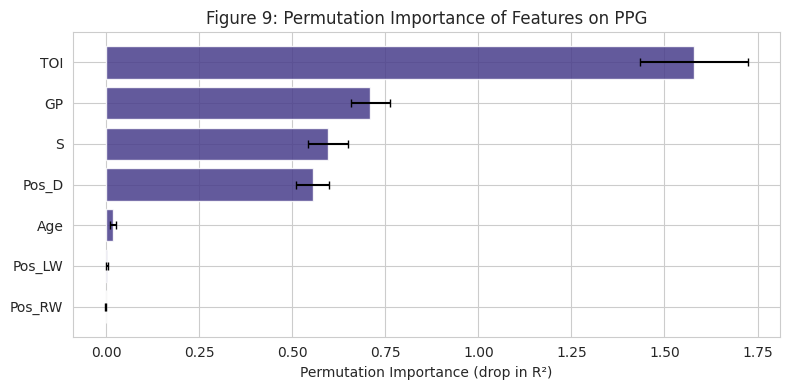

,feature,mean,std
0,TOI,1.5790,0.1451
1,GP,0.7102,0.0526
2,S,0.5966,0.0537
3,Pos_D,0.5554,0.0440
4,Age,0.0178,0.0082
5,Pos_LW,0.0034,0.0026
6,Pos_RW,-0.0010,0.0012


In [21]:
perm = permutation_importance(gb_q3, X3_test, y3_test,
                              n_repeats=20, random_state=RANDOM_STATE,
                              n_jobs=-1)
imp_q3 = pd.DataFrame({
    'feature': X3.columns,
    'mean': perm.importances_mean,
    'std':  perm.importances_std
}).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_q3['feature'], imp_q3['mean'],
        xerr=imp_q3['std'], color='darkslateblue', alpha=0.85,
        error_kw={'ecolor': 'black', 'capsize': 3})
ax.set_xlabel('Permutation Importance (drop in R²)')
ax.set_title('Figure 9: Permutation Importance of Features on PPG')
plt.tight_layout()
plt.show()

imp_q3.iloc[::-1].round(4).reset_index(drop=True)

**Interpretation.** Time on ice (TOI), games played (GP), and shots (S)
dominate the model — these capture *opportunity* and *volume*, which directly
drive points-per-game. Position (D vs. F) is the next-largest factor, since
defensemen score at lower rates than forwards. **Age** has small but
non-zero importance — it's a real signal, but its effect is much smaller
than the opportunity features.

### 6.2 Partial Dependence Plot for Age

A PDP shows the **average effect of age on predicted PPG**, after marginalizing
over all the other features. This is the "peak age curve" we hypothesized,
isolated cleanly from the confounding influence of opportunity and position.

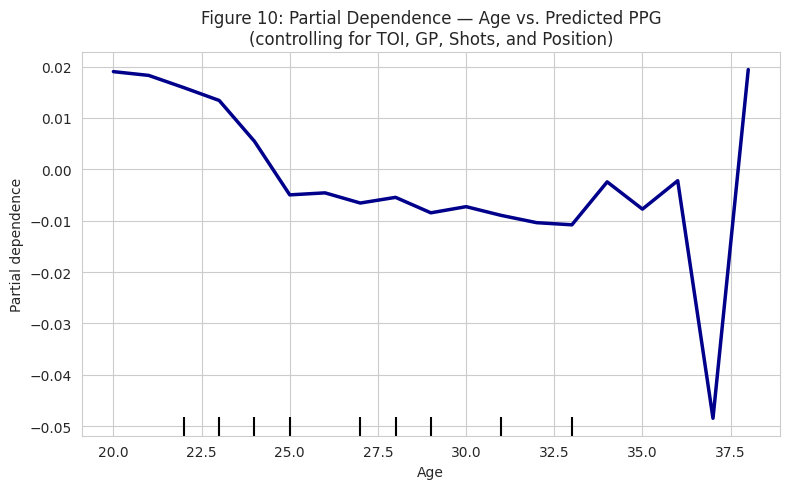

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    gb_q3, X3_train, ['Age'], ax=ax,
    line_kw={'lw': 2.5, 'color': 'darkblue'},
    grid_resolution=50)
ax.set_title('Figure 10: Partial Dependence — Age vs. Predicted PPG\n'
             '(controlling for TOI, GP, Shots, and Position)')
ax.set_ylabel('Predicted Points per Game')
ax.set_xlabel('Age')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation.** This is a more nuanced result than our original
hypothesis predicted. Once we hold opportunity (TOI, GP, S) and position
constant, the partial dependence shows a **gradual decline from age 20
onward**, *not* a clean peak in the mid-20s. The total effect across the
20-36 range is small (about 0.03 PPG), but the trend is consistent.

This means the apparent "peak age curve" we see in raw data is largely an
**opportunity effect**: teams give their best ice time to players in their
mid-to-late 20s, and that opportunity drives most of the age-related
production differences. Once you give a young player the same opportunity
as a 28-year-old, the model thinks the young player will perform at least
as well — possibly slightly better.

### 6.3 Individual Conditional Expectation (ICE) plot

ICE plots show the age curve for **individual players** rather than the
average. Each thin line is one player; the bold line is the average (PDP).
If all the lines move in parallel, the age effect is consistent across
players. If they fan out, it means the age effect depends on player type.

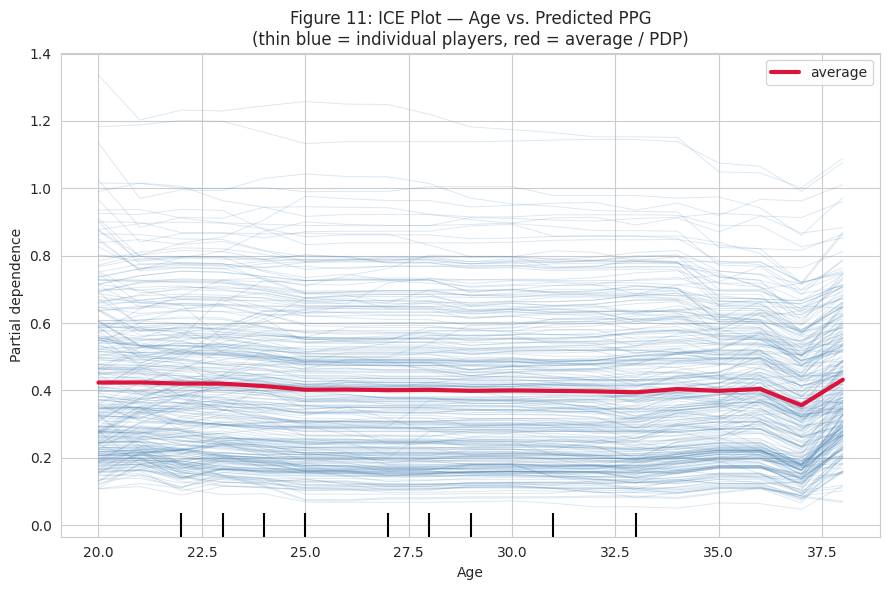

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
PartialDependenceDisplay.from_estimator(
    gb_q3, X3_train, ['Age'],
    kind='both',                          # both ICE lines and PDP average
    ice_lines_kw={'alpha': 0.18, 'color': 'steelblue', 'lw': 0.7},
    pd_line_kw={'color': 'crimson', 'lw': 3, 'linestyle': '-'},
    subsample=300,                        # 300 random ICE lines
    random_state=RANDOM_STATE,
    grid_resolution=50,
    ax=ax)
ax.set_title('Figure 11: ICE Plot — Age vs. Predicted PPG\n'
             '(thin blue = individual players, red = average / PDP)')
ax.set_ylabel('Predicted Points per Game')
ax.set_xlabel('Age')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation.** The ICE lines are largely flat with a slight
downward slope — confirming the PDP finding that age has only a small
effect on PPG once opportunity is held constant. The **vertical spread
between ICE lines is huge** (from ~0.1 PPG up to ~1.2 PPG), which is the
real story of NHL scoring: individual skill and role drive production far
more than age does.

### 6.4 Sanity check — the empirical age curve

Does the model's PDP match what we'd see by just averaging the raw data?

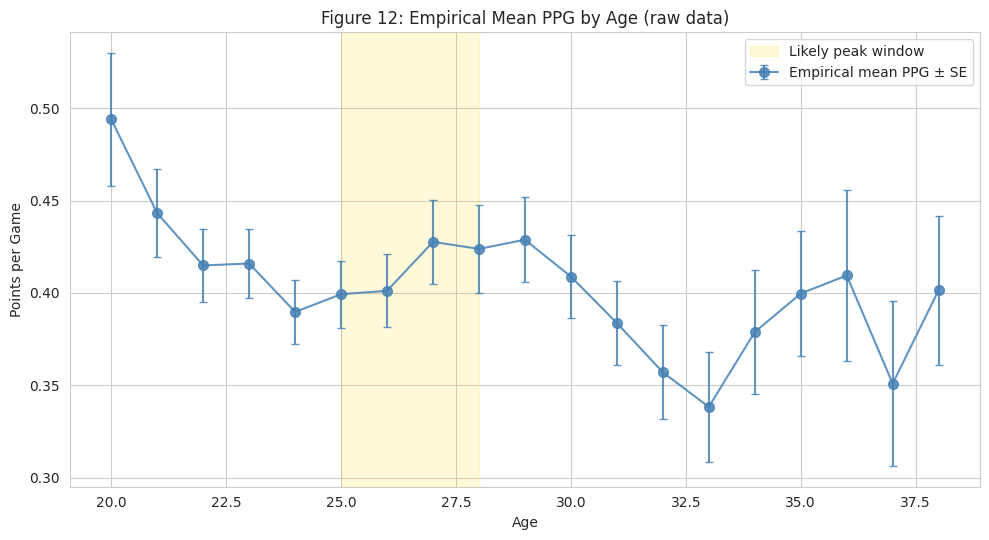

,Age,mean_ppg,std_ppg,n
0,20,0.494,0.236,43
1,21,0.443,0.193,66
2,22,0.415,0.210,111
3,23,0.416,0.219,135
4,24,0.390,0.228,172
5,25,0.399,0.229,158
6,26,0.401,0.230,137
7,27,0.428,0.254,123
8,28,0.424,0.257,115
9,29,0.429,0.247,116


In [24]:
# Empirical mean PPG by age (with sample sizes)
emp = reg.groupby('Age').agg(
    mean_ppg=('PPG', 'mean'),
    std_ppg=('PPG', 'std'),
    n=('PPG', 'count')
).reset_index()
emp = emp[emp['n'] >= 10]    # drop tiny age buckets

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(emp['Age'], emp['mean_ppg'],
            yerr=emp['std_ppg'] / np.sqrt(emp['n']),
            fmt='o-', color='steelblue', capsize=3, alpha=0.85,
            label='Empirical mean PPG ± SE', markersize=7, lw=1.5)
ax.set_xlabel('Age'); ax.set_ylabel('Points per Game')
ax.set_title('Figure 12: Empirical Mean PPG by Age (raw data)')
ax.axvspan(25, 28, alpha=0.15, color='gold', label='Likely peak window')
ax.legend()
plt.tight_layout()
plt.show()

emp.round(3)

## 7. Conclusions

### (Question 1) Predicting Total Points from the Player's Other Stats?
**Answer: YES, with high confidence.** Gradient Boosting predicted total
points with **CV R² ≈ 0.89** and test RMSE of **~6.5 points**, using only
peripheral stats (no goals or assists in the feature set). The model's
feature importances confirmed the initial hypothesis: **time on ice (TOI) and
shots on goal (S)** are by far the strongest predictors. Although Shots on goal (S) 
is the stronger predictor out of the two, with time on ice (TOI) being the 
secondary driver. This means a player's total points are largely a function of 
volume of shots, and then followed by opportunity (ice time).

### (Question 2) Identifying a Forward vs. a Defenseman?
**Answer: YES, with very high accuracy.** Both classifiers achieved
**~95% test accuracy** and **AUC ≈ 0.98**. The R² on predicted probabilities
was **~0.80**, indicating the models cleanly separate the two classes in
probability space. The most obvious features were **blocked shots
(BLK)** and **shooting percentage (S%)**. Defensemen block far more
shots and convert at lower rates than forwards.

### (Question 3) "Golden Age" Curve?
**Answer: PARTIALLY supported, but with an important detail.** The empirical
data (Figure 12) shows a small local peak in PPG around age **27-29** for
the bulk of NHL skaters, consistent with conventional sports analytics
wisdom. There's also a "survivor" driven spike at age 20-21, where only elite
prospects like MacKinnon and McDavid would be playing full NHL minutes that young.

However, the Partial Dependence Plot tells a different story. Once we
control for opportunity (TOI, GP, shots) and position, age has a small
decline from age 20 onward. There's no peak. This means the
visible mid-20s peak in raw data is largely an opportunity/selection
effect: teams give their best ice time to mid-20s players, and that's
what drives most of the apparent "peak age" pattern. The ICE plot confirms
this: individual skill (the vertical spread between ICE lines) dominates
age effects across the entire 20-38 range.

**Permutation Importance** 
Ranks age below all the opportunity features
(TOI, GP, shots) and below position. 
This would mean age, on its own, is a
relatively minor factor in predicting points-per-game.

## 8. Limitations and Next Steps
- We used only three seasons (2015-2017) for tractability. Adding more
  seasons would tighten estimates but introduce era effects (rule
  changes, scoring environment shifts).
- We did not control for team quality, line-mate effects, or
  power-play deployment.
- The dataset is observational. As we cannot truly isolate "the age effect" from
  the deployment decisions teams make based on a player's age.
- A good next step would be adding a **mixed-effects model** with player as
  a random effect to estimate within-player aging trajectories.

## 9. Sources / Tools Used

1. The AI tool used for this project was Claude.
Claude assisted with:
- Initial dataset exploration and choice of cleaning strategies
- Writing code for the EDA and modeling sections

The experience working with Claude went well. Claude was helpful in switching between modeling approaches and in explaining when a
certain technique (PDP vs. ICE) was the right tool for the question being asked.

2. I also visited a website called MoneyPuck, and despite the name, I didn't go there for gambling. Instead, I was fascinated with their data analytics on all players, goalies, teams, you name it. Seeing all the different statistics tracked for certain players or teams is very daunting, overwhelming, and very interesting all at once. It helped me grasp a better appreciation for this project and also gained more understanding of how all these data statistics are tracked and utilized to create the best teams possible.
   [MoneyPuck Data Analytics](https://moneypuck.com/stats.htm)